In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree

import seaborn as sns
import pickle

In [12]:
df=pd.read_csv(r"C:\Users\HP\Downloads\breast-cancer.csv")

In [13]:
print(df)

           id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0      842302         M        17.99         10.38          122.80     1001.0   
1      842517         M        20.57         17.77          132.90     1326.0   
2    84300903         M        19.69         21.25          130.00     1203.0   
3    84348301         M        11.42         20.38           77.58      386.1   
4    84358402         M        20.29         14.34          135.10     1297.0   
..        ...       ...          ...           ...             ...        ...   
564    926424         M        21.56         22.39          142.00     1479.0   
565    926682         M        20.13         28.25          131.20     1261.0   
566    926954         M        16.60         28.08          108.30      858.1   
567    927241         M        20.60         29.33          140.10     1265.0   
568     92751         B         7.76         24.54           47.92      181.0   

     smoothness_mean  compa

In [14]:
##Data cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [15]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [16]:
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [17]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Length: 569, dtype: bool

In [19]:
X = df[[
    'radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'smoothness_mean',
    'compactness_mean',
    'concavity_mean']]
Y= df[['diagnosis']]

In [ ]:
print(X)
print(Y)

    YearsExperience
0               1.1
1               1.3
2               1.5
3               2.0
4               2.2
5               2.9
6               3.0
7               3.2
8               3.2
9               3.7
10              3.9
11              4.0
12              4.0
13              4.1
14              4.5
15              4.9
16              5.1
17              5.3
18              5.9
19              6.0
20              6.8
21              7.1
22              7.9
23              8.2
24              8.7
25              9.0
26              9.5
27              9.6
28             10.3
29             10.5
      Salary
0    39343.0
1    46205.0
2    37731.0
3    43525.0
4    39891.0
5    56642.0
6    60150.0
7    54445.0
8    64445.0
9    57189.0
10   63218.0
11   55794.0
12   56957.0
13   57081.0
14   61111.0
15   67938.0
16   66029.0
17   83088.0
18   81363.0
19   93940.0
20   91738.0
21   98273.0
22  101302.0
23  113812.0
24  109431.0
25  105582.0
26  116969.0
27  112635.0
28 

In [22]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [23]:
Reg=DecisionTreeClassifier()

In [24]:
Reg.fit(X_train,Y_train)

DecisionTreeClassifier()

In [25]:
Reg.predict(X_test)

array(['B', 'M', 'M', 'B', 'B', 'M', 'M', 'M', 'M', 'B', 'B', 'M', 'B',
       'M', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'M',
       'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M',
       'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'B',
       'B', 'M', 'M', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'B', 'M', 'B', 'M', 'M', 'M', 'M', 'M', 'M', 'B', 'B', 'B',
       'B', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'M', 'B', 'M', 'M',
       'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'M', 'M'], dtype=object)

In [26]:
print(Reg)

DecisionTreeClassifier()


In [27]:
Reg.score(X_train,Y_train)

1.0

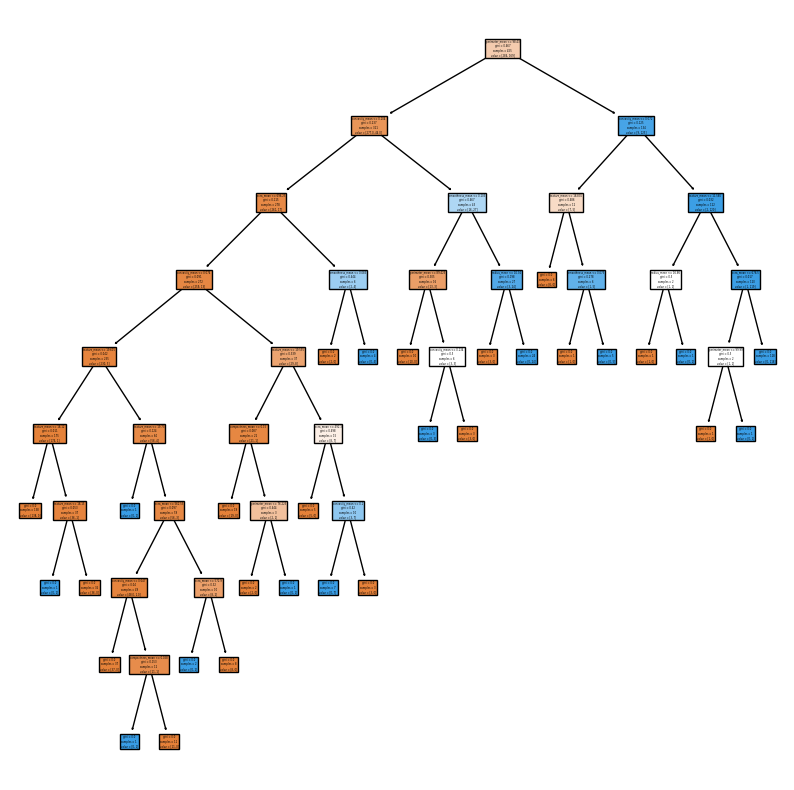

In [28]:
plt.figure(figsize=(10,10))
tree.plot_tree(
    Reg,
    filled=True,
    feature_names=X.columns)
plt.show()

In [31]:
with open("Breast_Cancer.pkl", "wb") as file:
    pickle.dump(Reg, file)
print("Model saved successfully")

Model saved successfully


In [ ]:
from tkinter import *
import pickle

# ---------------- Load Model ----------------
dtc = pickle.load(open("Breast_cancer.pkl", "rb"))

# ---------------- Window ----------------
root = Tk()
root.title("Breast Cancer Prediction System")
root.geometry("850x650")
root.configure(bg="#003366")

# ---------------- Heading ----------------
heading = Label(
    root,
    text="🩺 Breast Cancer Prediction System",
    font=("Georgia", 22, "bold"),
    bg="#003366",
    fg="white"
)
heading.pack(pady=20)

# ---------------- Frame ----------------
frame = Frame(root, bg="#EAF4FF", bd=5, relief=RIDGE)
frame.pack(pady=10)

labels = [
    "Radius Mean",
    "Texture Mean",
    "Perimeter Mean",
    "Area Mean",
    "Smoothness Mean",
    "Compactness Mean",
    "Concavity Mean"
]

entries = []

for i, text in enumerate(labels):

    Label(
        frame,
        text=text,
        font=("Arial", 13, "bold"),
        bg="#EAF4FF",
        fg="#003366"
    ).grid(row=i, column=0, padx=20, pady=10, sticky="w")

    e = Entry(
        frame,
        width=25,
        font=("Arial", 13),
        bd=3,
        relief=GROOVE
    )
    e.grid(row=i, column=1, padx=20, pady=10)

    entries.append(e)

# ---------------- Prediction Function ----------------
def predict():
    try:
        radius = float(entries[0].get())
        texture = float(entries[1].get())
        perimeter = float(entries[2].get())
        area = float(entries[3].get())
        smoothness = float(entries[4].get())
        compactness = float(entries[5].get())
        concavity = float(entries[6].get())

        prediction = Reg.predict([[
            radius,
            texture,
            perimeter,
            area,
            smoothness,
            compactness,
            concavity
        ]])

        if prediction[0] == 1:
            output.config(
                text="Prediction : Malignant",
                fg="red"
            )
        else:
            output.config(
                text="Prediction : Benign",
                fg="green"
            )

    except ValueError:
        output.config(
            text="Please enter valid numeric values!",
            fg="yellow"
        )

# ---------------- Button ----------------
Button(
    root,
    text="Predict",
    font=("Arial", 15, "bold"),
    bg="#0059B3",
    fg="white",
    activebackground="#0073E6",
    activeforeground="white",
    padx=25,
    pady=8,
    command=predict
).pack(pady=20)

# ---------------- Output ----------------
output = Label(
    root,
    text="Prediction",
    font=("Arial", 18, "bold"),
    bg="#003366",
    fg="#FFD700"
)
output.pack(pady=15)

# ---------------- Footer ----------------
footer = Label(
    root,
    text="Developed using Decision Tree Classifier",
    font=("Arial", 11),
    bg="#003366",
    fg="#B3D9FF"
)
footer.pack(side=BOTTOM, pady=10)

root.mainloop()